<a href="https://colab.research.google.com/github/Hiero-o/cp_02_sers/blob/main/cp_02_sers_2sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##EXE

treinar um modelo preditivo de classificação usando regressão logística (Diretamentedo sklearn) para prever se a rede elétrica está "estável" ou "instável" com base no dataset "Electrical Grid Stability Simulated Data
"

fonte:https://archive.ics.uci.edu/dataset/471/electrical+grid+stability+simulated+data

# Preaparação do ambiente

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Algoritmo de regressão logística
from sklearn.linear_model import LogisticRegression
# KNN, Decision Tree, SVM...

# Separação de dados de treino e teste (x_train, X_test, y_train, y_test)

from sklearn.model_selection import train_test_split

#Metricas de avaliação do modelo
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Carregamento dos dados e criação do DATAFRAME

In [68]:
dados = pd.read_csv('https://raw.githubusercontent.com/Hiero-o/cp_02_sers/refs/heads/main/Data_for_UCI_named.csv')

In [69]:
dados.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [70]:
# Quantas classes temos na coluna 'stabf'
dados['stabf'].unique()

array(['unstable', 'stable'], dtype=object)

In [71]:
# Quantos registros de cada classe
dados['stabf'].value_counts()

,count
stabf,
unstable,6380
stable,3620


In [72]:
# Estatísticas descritivas
# Para colunas categóricas

dados.describe(include='object')

,stabf
count,10000
unique,2
top,unstable
freq,6380


In [73]:
dados.columns

Index(['tau1', 'tau2', 'tau3', 'tau4', 'p1', 'p2', 'p3', 'p4', 'g1', 'g2',
       'g3', 'g4', 'stab', 'stabf'],
      dtype='object')

In [74]:
# Dados de entrada ---------> Features ------> variáveis independentes -------> X (maiusculo)

X = dados.drop(['stabf', 'stab'], axis=1)

X.head()

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923


In [75]:
# Dados de saída ---------> target --------------> variável dependente -------------> array y (minusculo)

y = dados['stabf']

y.head()

,stabf
0,unstable
1,stable
2,unstable
3,unstable
4,unstable


In [76]:
# Separação de dados de treino e teste
# X_train, x_test, y_train, y_test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=16)

X.shape

(10000, 12)

In [77]:
X_train.shape

(8000, 12)

In [78]:
X_test.shape


(2000, 12)

# Treinamento do modelo preditivo de classificação

In [79]:
# Instanciando o modelo com base no algoritmo (LogisticRegression)
modelo_lr = LogisticRegression()

In [80]:
# Treinamento do modelo

modelo_lr.fit(X_train, y_train)

LogisticRegression()

In [81]:
# Gerando as previsões

y_pred = modelo_lr.predict(X_test)

y_pred

array(['stable', 'unstable', 'unstable', ..., 'unstable', 'stable',
       'stable'], dtype=object)

In [82]:
#Avaliar o modelo

acuracia = 100 * accuracy_score(y_test, y_pred)

print(f"A acurácia do meu primeiro modelo de teste (perdi o cabaço), de regressão logística é {acuracia:.2f}%")

A acurácia do meu primeiro modelo de teste (perdi o cabaço), de regressão logística é 83.10%


In [ ]:
# Matriz de confusão usando o matplotlib e o seaborn

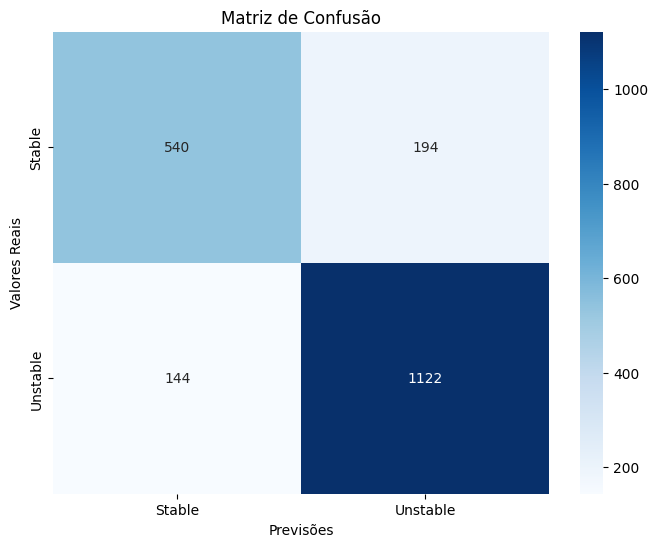

In [83]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stable', 'Unstable'], yticklabels=['Stable', 'Unstable'])
plt.title('Matriz de Confusão')
plt.xlabel('Previsões')
plt.ylabel('Valores Reais')
plt.show()